In [23]:
import os
import pandas as pd
import numpy as np  
import re
import sys
import subprocess
from PIL import Image
import io
import matplotlib.pyplot as plt
# import fitz  # PyMuPDF

### Analyze the results - OLD ###

In [21]:
# old path 
result_path = os.path.join(os.getcwd(), 'log','old','results')

# walk through directory and list all the subdirectories in a list
subdirs = [d for d in os.listdir(result_path) if os.path.isdir(os.path.join(result_path, d))]

data_list = []

model_name_pattern = r'_(iTransformer|PatchTST|SegRNN|TimeXer)_'
model_id_pattern = r'long_term_forecast_([^_]+)_'
model_config_pattern = r'sl(\d+)_ll(\d+)_pl(\d+)_dm(\d+)_nh(\d+)_el(\d+)_dl(\d+)_df(\d+)'

for subdir in subdirs:

    model_config_match = re.search(model_config_pattern, subdir)
    model_name_match = re.search(model_name_pattern, subdir)
    model_id_match = re.search(model_id_pattern, subdir)

    sl, ll, pl, dm, nh, el, dl, df = model_config_match.groups() if model_config_match else None    
    model_name = model_name_match.group(1) if model_name_match else None
    model_id = model_id_match.group(1) if model_id_match else None

    metrics_path = os.path.join(result_path, subdir, 'metrics.npy')
    if os.path.exists(metrics_path):
        metrics = np.load(metrics_path, allow_pickle=True)
        # Map by position: [mae, mse, rmse, mape, mspe]
        mae = metrics[0] if len(metrics) > 0 else None
        mse = metrics[1] if len(metrics) > 1 else None
        rmse = metrics[2] if len(metrics) > 2 else None
        mape = metrics[3] if len(metrics) > 3 else None
        mspe = metrics[4] if len(metrics) > 4 else None
        data_list.append({
            'subdir': subdir,
            'model_id': model_id.upper(), 
            'model_name': model_name,
            'seq_len': sl, 
            'lab_len': ll,
            'pred_len': pl,
            'dim_model': dm,
            'dim_fcn': df,
            'enc_layer': el,
            'dec_layer': dl,
            'num_heads': nh,
            'mae': mae,
            'mse': mse,
            'rmse': rmse,
            'mape': mape,
            'mspe': mspe
        })
    else:
        print(f"metrics.npy not found in {model_id}")

old = pd.DataFrame(data_list)
# old.to_csv(os.path.join(os.getcwd(), 'log','old','results','summary_old.csv'), index=False)


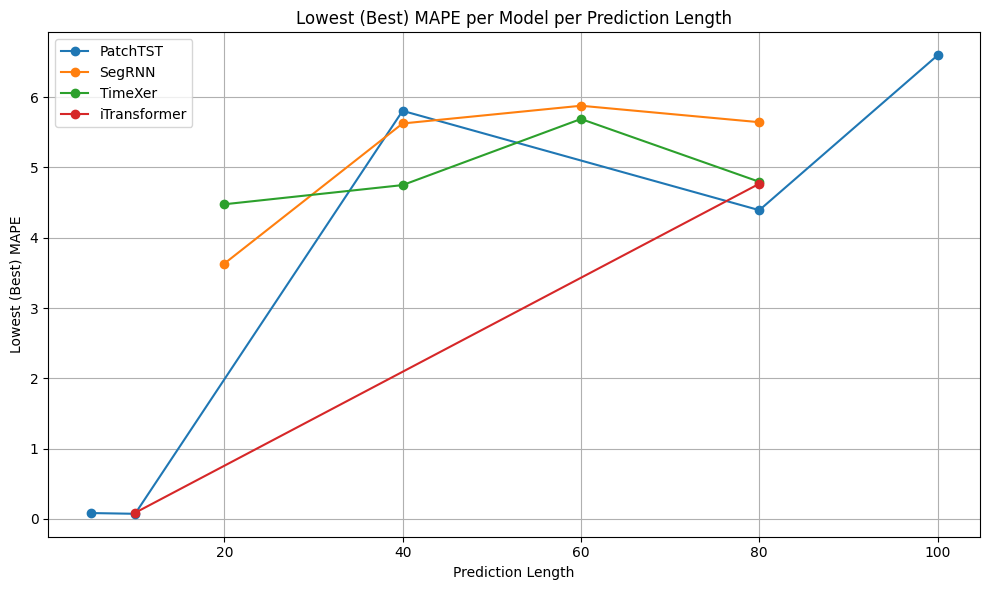

In [22]:


df_metrics=old

# Ensure pred_len is numeric for grouping
df_metrics['pred_len'] = pd.to_numeric(df_metrics['pred_len'])

# Group by model_name and pred_len, find row with lowest (best) mape in each group
best_mape = df_metrics.loc[df_metrics.groupby(['model_name', 'pred_len'])['mape'].idxmin()]

# Plot best (lowest) mape per model per pred_len
plt.figure(figsize=(10, 6))
for model in best_mape['model_name'].unique():
    subset = best_mape[best_mape['model_name'] == model]
    plt.plot(subset['pred_len'], subset['mape'], marker='o', label=model)

plt.xlabel('Prediction Length')
plt.ylabel('Lowest (Best) MAPE')
plt.title('Lowest (Best) MAPE per Model per Prediction Length')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Analyze the results - NEW ###

In [24]:

# new path
result_path = os.path.join(os.getcwd(), 'results')

# walk through directory and list all the subdirectories in a list
subdirs = [d for d in os.listdir(result_path) if os.path.isdir(os.path.join(result_path, d))]
# print(subdirs_old)

data_list = []

model_name_pattern = r'_(iTransformer|PatchTST|SegRNN|TimeXer)_'
model_id_pattern = r'long_term_forecast_([^_]+_[^_]+)_'
model_config_pattern = r'sl(\d+)_ll(\d+)_pl(\d+)_dm(\d+)_nh(\d+)_el(\d+)_dl(\d+)_df(\d+)'

for subdir in subdirs:

    model_config_match = re.search(model_config_pattern, subdir)
    model_name_match = re.search(model_name_pattern, subdir)
    model_id_match = re.search(model_id_pattern, subdir)

    sl, ll, pl, dm, nh, el, dl, df = model_config_match.groups() if model_config_match else None    
    model_name = model_name_match.group(1) if model_name_match else None
    model_id = model_id_match.group(1) if model_id_match else None

    metrics_path = os.path.join(result_path, subdir, 'metrics.npy')
    if os.path.exists(metrics_path):
        metrics = np.load(metrics_path, allow_pickle=True)
        # Map by position: [mae, mse, rmse, mape, mspe]
        mae = metrics[0] if len(metrics) > 0 else None
        mse = metrics[1] if len(metrics) > 1 else None
        rmse = metrics[2] if len(metrics) > 2 else None
        mape = metrics[3] if len(metrics) > 3 else None
        mspe = metrics[4] if len(metrics) > 4 else None
        data_list.append({
            'subdir': subdir,
            'model_id': model_id, 
            'model_name': model_name,
            'seq_len': sl, 
            'lab_len': ll,
            'pred_len': pl,
            'dim_model': dm,
            'dim_fcn': df,
            'enc_layer': el,
            'dec_layer': dl,
            'num_heads': nh,
            'mae': mae,
            'mse': mse,
            'rmse': rmse,
            'mape': mape,
            'mspe': mspe
        })
    else:
        print(f"metrics.npy not found in {model_id}")

new = pd.DataFrame(data_list)
new.to_csv(os.path.join(os.getcwd(), 'results','summary.csv'), index=False)

### check anomaly ###

In [6]:
## check anomaly between mse and mape 
# For each combination, check if the row with lowest mse is different from the row with lowest mape

df_metrics=new

diff_rows = []

grouped = df_metrics.groupby(['model_id', 'model_name', 'pred_len'])
for key, group in grouped:
    min_mse_idx = group['mse'].idxmin()
    min_mape_idx = group['mape'].idxmin()
    if min_mse_idx != min_mape_idx:
        diff_rows.append({
            'model_id': key[0],
            'model_name': key[1],
            'pred_len': key[2],
            'min_mse_idx': min_mse_idx,
            'min_mape_idx': min_mape_idx
        })

if diff_rows:
    print("Combinations where lowest mse and lowest mape are NOT in the same row:")
    indices = []
    for row in diff_rows:
        print(row)
        indices.extend([row['min_mse_idx'], row['min_mape_idx']])
    indices = list(set(indices))
    df_metrics.loc[indices].to_csv('diff_rows_indices.csv', index=True)
    print(f"Written {len(indices)} rows to diff_rows_indices.csv")
else:
    print("For all combinations, lowest mse and lowest mape are in the same row.")

Combinations where lowest mse and lowest mape are NOT in the same row:
{'model_id': 'ALL_clean', 'model_name': 'SegRNN', 'pred_len': '120', 'min_mse_idx': 30, 'min_mape_idx': 26}
{'model_id': 'ALL_clean', 'model_name': 'TimeXer', 'pred_len': '120', 'min_mse_idx': 46, 'min_mape_idx': 37}
{'model_id': 'ALL_clean', 'model_name': 'iTransformer', 'pred_len': '120', 'min_mse_idx': 9, 'min_mape_idx': 8}
{'model_id': 'ALL_clean', 'model_name': 'iTransformer', 'pred_len': '40', 'min_mse_idx': 3, 'min_mape_idx': 5}
{'model_id': 'ALL_clean', 'model_name': 'iTransformer', 'pred_len': '80', 'min_mse_idx': 10, 'min_mape_idx': 7}
Written 10 rows to diff_rows_indices.csv


### Select Best Models ###

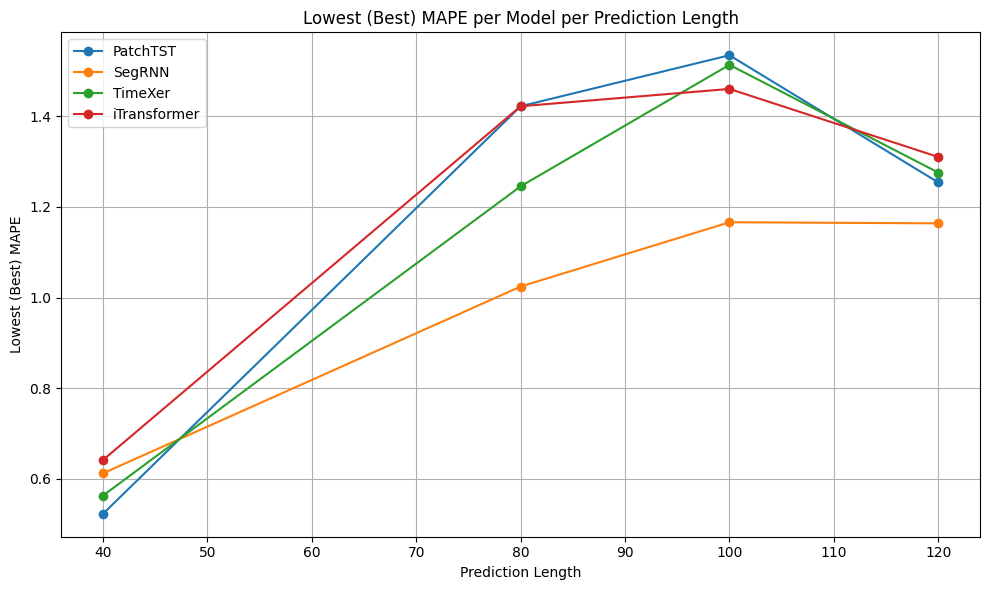

In [ ]:


df_metrics=new


# Ensure pred_len is numeric for grouping
df_metrics['pred_len'] = pd.to_numeric(df_metrics['pred_len'])

# Group by model_name and pred_len, find row with lowest (best) mape in each group
best_mape = df_metrics.loc[df_metrics.groupby(['model_name', 'pred_len'])['mape'].idxmin()]

# Plot best (lowest) mape per model per pred_len
plt.figure(figsize=(10, 6))
for model in best_mape['model_name'].unique():
    subset = best_mape[best_mape['model_name'] == model]
    plt.plot(subset['pred_len'], subset['mape'], marker='o', label=model)

plt.xlabel('Prediction Length')
plt.ylabel('Lowest (Best) MAPE')
plt.title('Lowest (Best) MAPE per Model per Prediction Length')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# Best model selection group by pred_len

df_metrics=new

df_metrics['pred_len'] = pd.to_numeric(df_metrics['pred_len'], errors='coerce')

# Filter for pred_len >= 40 
filtered = df_metrics[df_metrics['pred_len'] >= 40]

# Select the row with the lowest mape for each pred_len
lowest_mape_rows = filtered.loc[filtered.groupby('pred_len')['mape'].idxmin()]
lowest_mape_rows.head(10)
lowest_mape_rows.to_csv(os.path.join(os.getcwd(), 'results','temp.csv'), index=False)

In [ ]:
df_metrics = new

# Best model selection group by pred_len
# Ensure pred_len is numeric for comparison

df_metrics['pred_len'] = pd.to_numeric(df_metrics['pred_len'])

# Filter for pred_len >= 40
filtered = df_metrics[df_metrics['pred_len'] >= 40]

# Select the row with the lowest mape for each pred_len
lowest_mape_rows = filtered.loc[filtered.groupby('pred_len')['mape'].idxmin()]

# lowest_mape_rows.to_csv(os.path.join(os.getcwd(), 'results','temp.csv'), index=False)

# for dir in lowest_mape_rows['subdir']:
#     pdf_path=os.path.join(os.getcwd(), 'log','old','test_results', dir)
#     # open the .pdf file in pdf path    
#     if sys.platform.startswith('win'):
#         os.startfile(pdf_path)
#     elif sys.platform.startswith('darwin'):
#         subprocess.run(['open', pdf_path])
#     else:
#         subprocess.run(['xdg-open', pdf_path])



In [ ]:
# # Display the first page of the PDF as an image in the notebook
# # NOT working 
# pdf_document = fitz.open(pdf_path)
# page = pdf_document.load_page(0)
# pix = page.get_pixmap(dpi=150)
# img = Image.open(io.BytesIO(pix.tobytes()))
# img.show()


In [13]:
var='./test_results/long_term_forecast_ALL_clean_SegRNN_hpi_ftMS_sl160_ll20_pl40_dm512_nh14_el2_dl1_df2048_expand2_dc4_fc3_ebtimeF_dtTrue_Exp_0/clean_AUS_pred_80_0.pdf'
# name=var.split('/')[-1]
# # replace .pdf and number from name 
# # Remove '.pdf' and trailing digits from the filename
# name_no_ext = re.sub(r'\d+\.pdf$', '', var.split('/')[-1])
# # Extract 'clean_AUS_pred_80' from var

extracted_str=var.split('/')[-1].split('.')[0]
print(extracted_str)

# match = re.search(r'([A-Z|a-z]+[A-Z|a-z]+_pred_\d+)', name)
# if match:
#     extracted_str = match.group(1)
#     print(extracted_str)
# else:
#     print("Pattern not found.")


clean_AUS_pred_80_0


clean_AUS_pred_80_0


clean_AUS


### Result visualization ###

In [ ]:
import matplotlib.pyplot as plt

df_metrics = old

# Ensure numeric types for plotting
df_metrics['seq_len'] = pd.to_numeric(df_metrics['seq_len'])
df_metrics['lab_len'] = pd.to_numeric(df_metrics['lab_len'])
df_metrics['pred_len'] = pd.to_numeric(df_metrics['pred_len'])

# Filter for pred_len >= 40
filtered_df = df_metrics[df_metrics['pred_len'] >= 40]

# Group by model_id, model_name, pred_len
grouped = filtered_df.groupby(['model_id', 'model_name', 'pred_len'])
# grouped = filtered_df.groupby(['model_id', 'model_name', 'pred_len'])

for (model_id, model_name, pred_len), group in grouped:
    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle(f"Model: {model_name}, ID: {model_id}, pred_len: {pred_len}")

    # Plot MAPE
    sc = ax.scatter(group['seq_len'], group['lab_len'], c=group['mape'], cmap='plasma', s=100)
    ax.set_title('MAPE')
    ax.set_xlabel('seq_len')
    ax.set_ylabel('lab_len')
    plt.colorbar(sc, ax=ax, label='MAPE')

    # Highlight lowest MAPE
    min_mape_idx = group['mape'].idxmin()
    min_mape_row = group.loc[min_mape_idx]
    ax.scatter(min_mape_row['seq_len'], min_mape_row['lab_len'], color='red', s=200, edgecolor='black', label='Lowest MAPE')
    ax.legend()
    print(f"Lowest MAPE for {model_id}, {model_name}, pred_len={pred_len}: {min_mape_row['mape']:.4f} at subdir: {min_mape_row['subdir']}")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# df_metrics = new

# # Unique combinations of model_id, model_name, and pred_len
# combinations = df_metrics[['model_id', 'model_name', 'pred_len']].drop_duplicates()

# # Plotting
# for _, row in combinations.iterrows():
#     model_id = row['model_id']
#     model_name = row['model_name']
#     pred_len = row['pred_len']
    
#     subset = df_metrics[(df_metrics['model_id'] == model_id) & 
#                         (df_metrics['model_name'] == model_name) & 
#                         (df_metrics['pred_len'] == pred_len)]
    
#     plt.figure(figsize=(12, 6))
#     # sns.lineplot(data=subset, x='seq_len', y='mse', marker='o', label='MSE')
#     sns.lineplot(data=subset, x='seq_len', y='mape', marker='o', label='MAPE')
    
#     # Highlight the lowest points
#     # min_mse_idx = subset['mse'].idxmin()
#     min_mape_idx = subset['mape'].idxmin()
    
#     # plt.scatter(subset.loc[min_mse_idx, 'seq_len'], subset.loc[min_mse_idx, 'mse'], color='red', zorder=5)
#     plt.scatter(subset.loc[min_mape_idx, 'seq_len'], subset.loc[min_mape_idx, 'mape'], color='blue', zorder=5)
    
#     # plt.text(subset.loc[min_mse_idx, 'seq_len'], subset.loc[min_mse_idx, 'mse'], 
#     #          f"Min MSE: {subset.loc[min_mse_idx, 'subdir']}", 
#     #          horizontalalignment='right', color='red')
    
#     # plt.text(subset.loc[min_mape_idx, 'seq_len'], subset.loc[min_mape_idx, 'mape'], 
#     #          f"Min MAPE: {subset.loc[min_mape_idx, 'subdir']}", 
#     #          horizontalalignment='right', color='blue')
    
#     plt.title(f'Model: {model_name} (ID: {model_id}), Prediction Length: {pred_len}')
#     plt.xlabel('Sequence Length')
#     plt.ylabel('Error')
#     plt.legend()
#     plt.grid(True)
#     plt.show()



In [ ]:
import os
import sys
# Go up two levels from current dir
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
# Add the parent directory to sys.path
sys.path.append(parent_dir)

import numpy as np
import pandas as pd
import glob
import re
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from utils.timefeatures import time_features
from data_provider.m4 import M4Dataset, M4Meta
from data_provider.uea import subsample, interpolate_missing, Normalizer
from sktime.datasets import load_from_tsfile_to_dataframe
import warnings
from utils.augmentation import run_augmentation_single

In [ ]:
path='C:\\GitHub\Time-Series-Library\dataset\hpi\cropped_CAN.csv'
target = 'OT'

df_raw = pd.read_csv(path)

In [ ]:
path='C:\\GitHub\Time-Series-Library\dataset\hpi\cropped_CAN.csv'

target = 'OT'
# assert flag in ['train', 'test', 'val']
flag = 'train'
seq_len = 80

type_map = {'train': 0, 'val': 1, 'test': 2}
set_type = type_map[flag]

df_raw = pd.read_csv(path)
print('DATA SHAPE: ', df_raw.shape)

cols = list(df_raw.columns)
cols.remove(target)
cols.remove('date')
df_raw = df_raw[['date'] + cols + [target]]
num_train = int(len(df_raw) * 0.7)
num_test = int(len(df_raw) * 0.2)
num_vali = len(df_raw) - num_train - num_test
print('NUM TRAIN: ', num_train, 'NUM TEST: ', num_test, 'NUM VALI: ', num_vali) 
border1s = [0, num_train - seq_len, len(df_raw) - num_test - seq_len]
border2s = [num_train, num_train + num_vali, len(df_raw)]
border1 = border1s[set_type]
border2 = border2s[set_type]
df_raw.head(10)


In [ ]:
df_stamp = df_raw[['date']][border1:border2]
df_stamp

In [ ]:
# df_stamp['date'] = pd.to_datetime(df_stamp.date)
# df_stamp

In [ ]:
df_stamp['date'] = pd.to_datetime(df_stamp['date'].astype(str), format='%Y%m%d')

In [ ]:
df_stamp['month'] = df_stamp.date.apply(lambda row: row.month, 1)
df_stamp['day'] = df_stamp.date.apply(lambda row: row.day, 1)
df_stamp['weekday'] = df_stamp.date.apply(lambda row: row.weekday(), 1)
df_stamp['hour'] = df_stamp.date.apply(lambda row: row.hour, 1)
data_stamp = df_stamp.drop(['date'], 1).values
data_stamp

In [ ]:
df_stamp['year'] = df_stamp['date'].dt.year
df_stamp['quarter'] = df_stamp['date'].dt.quarter
df_stamp['month'] = df_stamp['date'].dt.month
data_stamp = df_stamp.drop(['date'], 1).values
data_stamp

In [ ]:
# df_stamp = df_raw[['date']][border1:border2]
# df_stamp
# df_stamp['date'] = pd.to_datetime(df_stamp.date)
# df_stamp
data_stamp = time_features(pd.to_datetime(df_stamp['date'].values), freq='M')
data_stamp
data_stamp = data_stamp.transpose(1, 0)
data_stamp

In [ ]:

df_raw['date'] = pd.to_datetime(df_raw['date'].astype(str), format='%Y%m%d')

# Extract time features
df_raw['year'] = df_raw['date'].dt.year
df_raw['quarter'] = df_raw['date'].dt.quarter
df_raw['month'] = df_raw['date'].dt.month

# Normalize/Scale time features
scaler = StandardScaler()
time_features = df_raw[['year', 'quarter', 'month']]
scaled_time_features = scaler.fit_transform(time_features)

# Add scaled features back to DataFrame
df_raw[['year_scaled', 'quarter_scaled', 'month_scaled']] = scaled_time_features

df_raw.head(200)


In [ ]:
df_raw.dtypes